# HH bbtautau Truth Matching Diagnostics

This notebook validates the matching chain before it is reduced to SPANet target indices.

VBF chain: `LHEPart status==1 light quark -> GenJet -> SPANetJet`.

HH b chain: `GenPart b from Higgs mother -> SPANetJet`.

The plots compare the matched truth and reco object kinematics and the matching distances.

In [5]:
from pathlib import Path
import sys

SPANET = Path('/home/norman/SPANet')
sys.path.insert(0, str(SPANET / 'utils'))

from convert_hh_bbtautau_parquet import expand_inputs, load_chunks
from plot_hh_bbtautau_matching import collect_matching, summarize, make_plots

INPUT = Path('/local/norman/UHHAnalysis/SPANet/22pre_v14/hh_vbf_hbb_htt_kv1_k2v1_kl1_madgraph/nominal/calib__default/sel__default/red__default/prod24/events_0.parquet')
PLOT_DIR = Path('/local/norman/UHHAnalysis/SPANet/plots/matching_diagnostics_kv1_k2v1_events0')

chunks = load_chunks(expand_inputs([INPUT]), max_events=50000)
hhb, vbf = collect_matching(
    chunks,
    source_collection='SPANetJet',
    hhb_dr=0.4,
    lhe_to_gen_dr=0.4,
    gen_to_reco_dr=0.3,
    use_overlap_cleaning=True,
)
summarize(hhb, vbf)

Matched object summary
  HH b matched objects: 30256
  VBF matched objects: 20554
HH b
  gen_reco_dr: mean=0.0626, median=0.0336, p95=0.2419
VBF
  gen_reco_dr: mean=0.0314, median=0.0234, p95=0.0853
  lhe_gen_dr: mean=0.0910, median=0.0555, p95=0.2954


In [6]:
make_plots(hhb, vbf, PLOT_DIR)
print(PLOT_DIR)

/local/norman/UHHAnalysis/SPANet/plots/matching_diagnostics_kv1_k2v1_events0


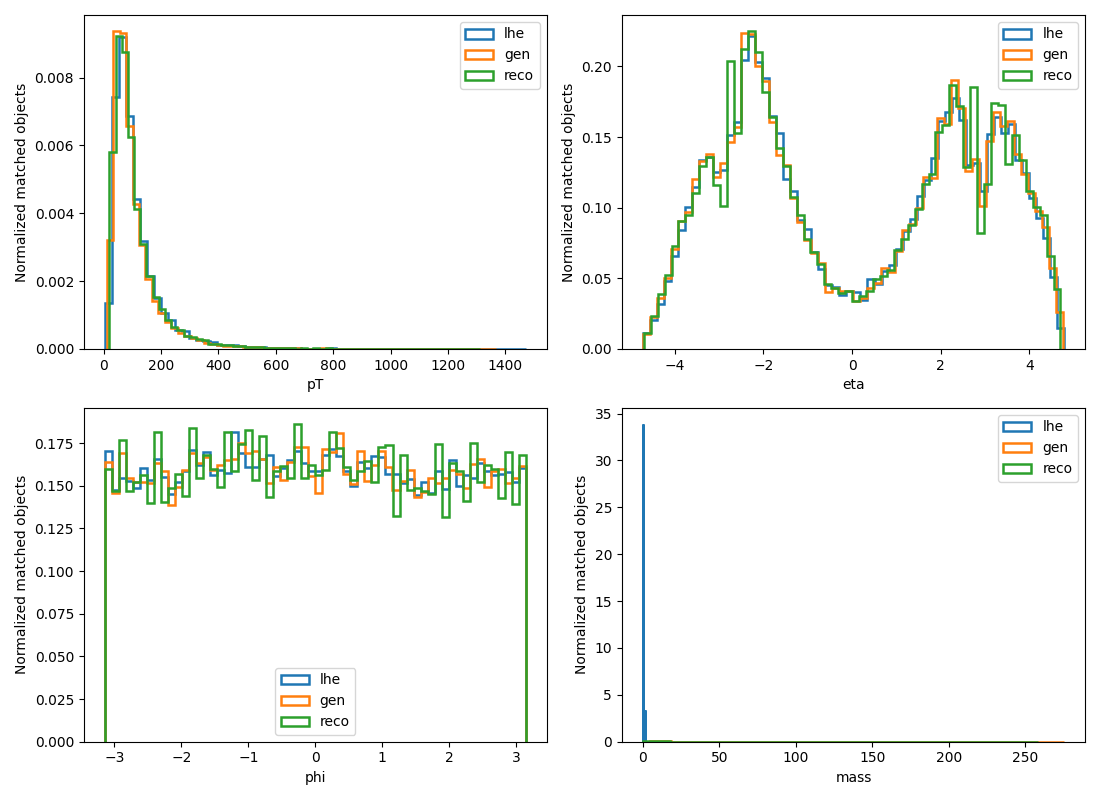

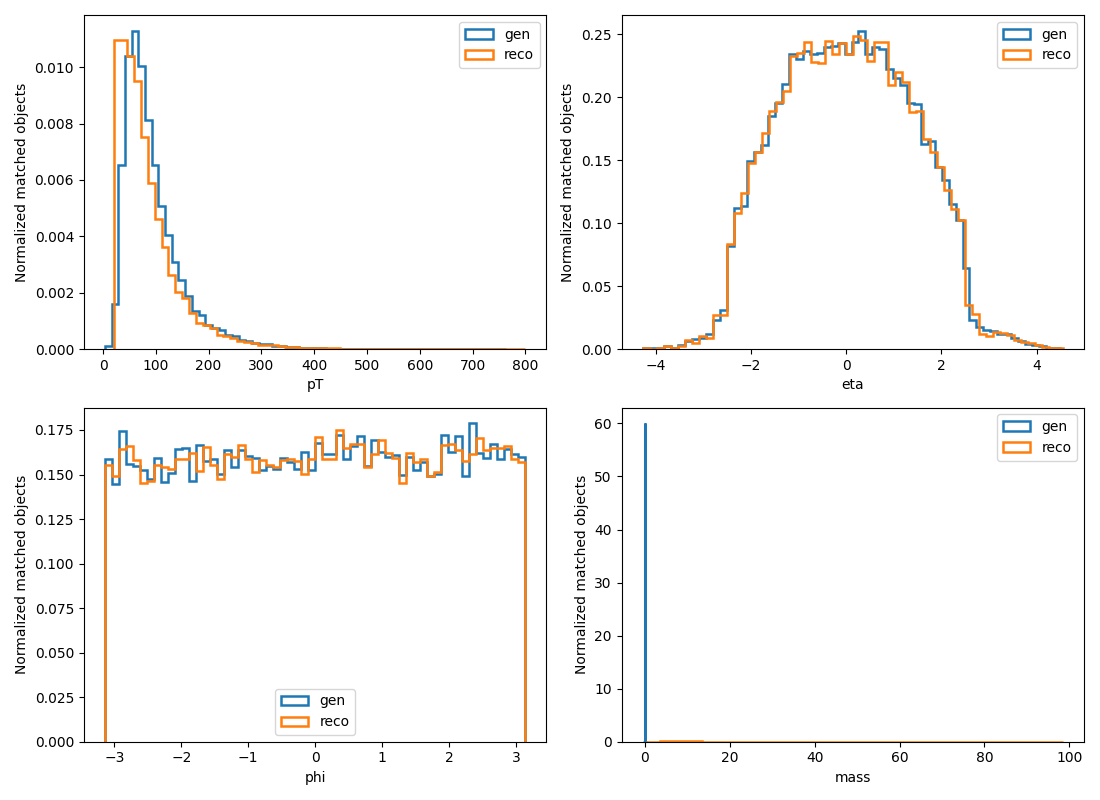

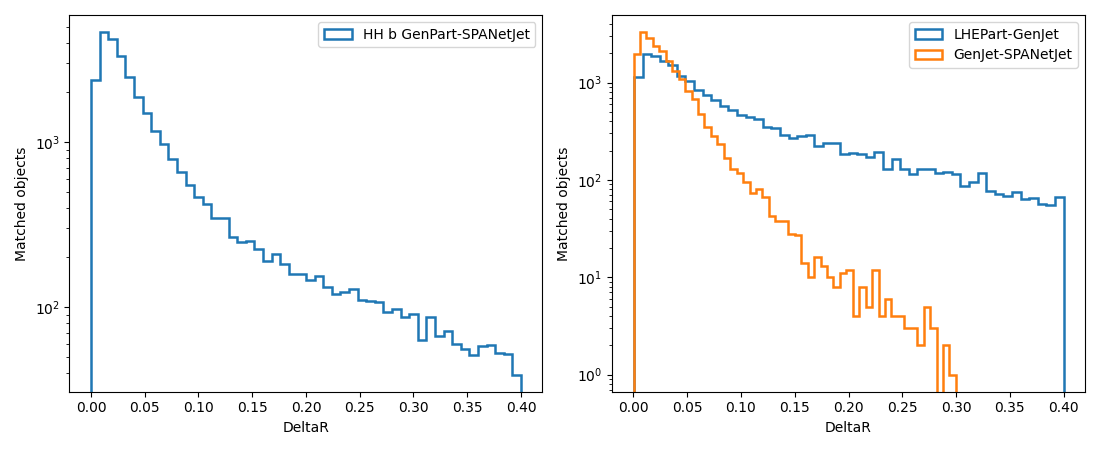

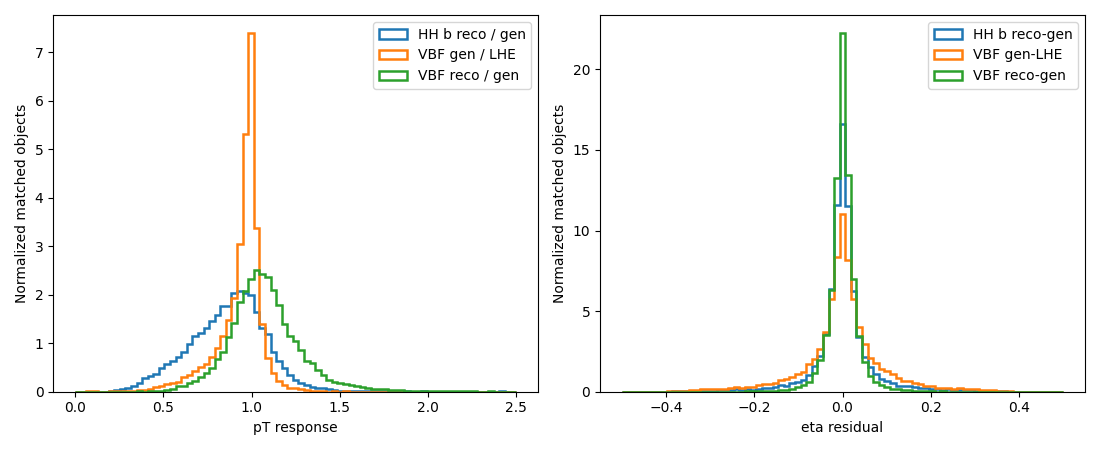

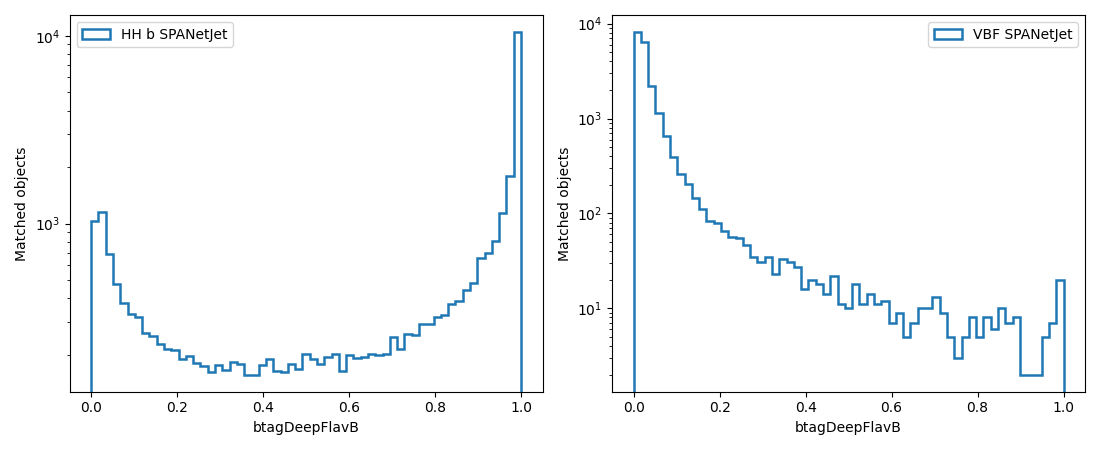

In [7]:
from IPython.display import Image, display

for name in [
    'vbf_matched_object_kinematics.png',
    'hhb_matched_object_kinematics.png',
    'matching_delta_r.png',
    'matching_response_residuals.png',
    'matched_reco_btag.png',
]:
    display(Image(filename=str(PLOT_DIR / name)))

In [8]:
# Numerical summaries useful for notes/talks.
import numpy as np

for label, data in [('HH b', hhb), ('VBF', vbf)]:
    print(label)
    for key in sorted(k for k in data if k.endswith('_dr')):
        values = data[key]
        print(f"  {key}: mean={np.mean(values):.4f}, median={np.median(values):.4f}, p95={np.percentile(values, 95):.4f}")

print('HH b reco/gen pt response:', np.median(hhb['reco_pt'] / hhb['gen_pt']))
print('VBF gen/LHE pt response:', np.median(vbf['gen_pt'] / vbf['lhe_pt']))
print('VBF reco/gen pt response:', np.median(vbf['reco_pt'] / vbf['gen_pt']))

HH b
  gen_reco_dr: mean=0.0626, median=0.0336, p95=0.2419
VBF
  gen_reco_dr: mean=0.0314, median=0.0234, p95=0.0853
  lhe_gen_dr: mean=0.0910, median=0.0555, p95=0.2954
HH b reco/gen pt response: 0.8850176778233495
VBF gen/LHE pt response: 0.971634954969386
VBF reco/gen pt response: 1.0575221514051352
